Filename : notebook_01.ipynb <br>
Description : Data Exploration

---

In [1]:
# =============================================================================
# Import Required Libraries
# =============================================================================
# Import 3 libraries หลักที่ใช้ใน notebook นี้:

# 1. NumPy (np) — Library สำหรับคำนวณทางคณิตศาสตร์และจัดการ Array
import numpy as np

# 2. Pandas (pd) — Library สำหรับจัดการและวิเคราะห์ข้อมูล (DataFrame, Series)
import pandas as pd

# 3. Matplotlib (plt) — Library สำหรับสร้างกราฟและ Data Visualization
import matplotlib.pyplot as plt

---

## 1. Generate Sample Data

**วัตถุประสงค์:** สร้าง DataFrame ตัวอย่างของลูกค้า 15 คน เพื่อใช้เป็นข้อมูลตั้งต้นของทุก Section

### โครงสร้างข้อมูล (7 คอลัมน์)

| คอลัมน์ | ชนิดข้อมูล | คำอธิบาย |
|---------|-----------|----------|
| `Cust_ID` | int | รหัสลูกค้า (1–15) |
| `Age` | int | อายุ (ปี) — Numerical |
| `Income` | int | รายได้ต่อเดือน (บาท) — Numerical |
| `Spend_SCR` | int | คะแนนการใช้จ่าย 0–100 — Numerical |
| `Gender` | object | เพศ M / F — Categorical |
| `Join_Date` | datetime | วันที่สมัครสมาชิก — Datetime |
| `Is_Member` | bool | สถานะสมาชิก — Boolean |

### Concept สำคัญ

**Dictionary → DataFrame** — วิธีที่ใช้บ่อยที่สุดในการสร้าง DataFrame จากข้อมูลที่เตรียมไว้เอง
```python
df = pd.DataFrame(data)   # key ของ dict กลายเป็นชื่อคอลัมน์
```
ทุก list ใน dict **ต้องมีความยาวเท่ากัน** ไม่เช่นนั้นจะเกิด `ValueError`

**`pd.date_range()`** — สร้างชุดวันที่อัตโนมัติ
```python
pd.date_range("2020-01-01", periods=15, freq="ME")
```
- `periods=15` → จำนวนวันที่ที่ต้องการ
- `freq="ME"` → Month End (วันสุดท้ายของเดือน) ใน pandas เวอร์ชันใหม่
  - เวอร์ชันเก่าใช้ `"M"` ซึ่งปัจจุบัน deprecated แล้ว

### ชนิดข้อมูลกับกราฟที่เหมาะสม
- **Numerical** (Age, Income, Spend_SCR) → Histogram, Box Plot, Scatter Plot
- **Categorical** (Gender, Is_Member) → Bar Chart, Pie Chart

In [2]:
# =============================================================================
# Section 1: Generate Sample Data
# =============================================================================
# สร้างข้อมูลตัวอย่างของลูกค้า 15 คน (15 rows)
# ข้อมูลประกอบด้วย 7 คอลัมน์:

data = {
    "Cust_ID": list(range(1, 16)),           # รหัสลูกค้า (1-15)
    "Age": [25, 32, 40, 28, 35, 45, 50, 29, 31, 38, 42, 27, 33, 36, 48],  # อายุ (ปี)
    "Income": [25000, 32000, 45000, 28000, 35000, 60000, 72000, 
               30000, 31000, 40000, 52000, 27000, 33000, 36000, 80000],  # รายได้ (บาท)
    "Spend_SCR": [60, 70, 55, 65, 75, 80, 90, 
                       50, 68, 72, 85, 58, 66, 74, 95],  # คะแนนการใช้จ่าย (0-100)
    "Gender": ["F","M","M","M","F","M","M","F","F","M","M","F","F","M","F"],  # เพศ (M=ชาย, F=หญิง)
    "Join_Date": pd.date_range("2020-01-01", periods=15, freq="ME"),  # วันที่สมัคร (สิ้นเดือน)
    "Is_Member": [True, True, False, True, False, True, True, 
                  False, True, True, False, True, False, True, True]  # สถานะสมาชิก
}

# แปลง Dictionary เป็น Pandas DataFrame
df = pd.DataFrame(data)

# แสดงข้อมูลทั้งหมดในตาราง
print(df)

    Cust_ID  Age  Income  Spend_SCR Gender  Join_Date  Is_Member
0         1   25   25000         60      F 2020-01-31       True
1         2   32   32000         70      M 2020-02-29       True
2         3   40   45000         55      M 2020-03-31      False
3         4   28   28000         65      M 2020-04-30       True
4         5   35   35000         75      F 2020-05-31      False
5         6   45   60000         80      M 2020-06-30       True
6         7   50   72000         90      M 2020-07-31       True
7         8   29   30000         50      F 2020-08-31      False
8         9   31   31000         68      F 2020-09-30       True
9        10   38   40000         72      M 2020-10-31       True
10       11   42   52000         85      M 2020-11-30      False
11       12   27   27000         58      F 2020-12-31       True
12       13   33   33000         66      F 2021-01-31      False
13       14   36   36000         74      M 2021-02-28       True
14       15   48   80000 

---

## 2. Histogram — การกระจายตัวของข้อมูล

**วัตถุประสงค์:** ดูรูปร่างการกระจายตัว (Distribution) ของ `Income` พร้อมเปรียบเทียบ Mean / Median / Mode

### Histogram คืออะไร?
กราฟแท่งที่แบ่งข้อมูลตัวเลขออกเป็นช่วง ๆ เรียกว่า **bin** แล้วนับความถี่ในแต่ละช่วง
ใช้ตอบคำถามว่า *ข้อมูลกระจุกตัวอยู่ช่วงไหน* และ *เบ้ไปทางใด*

> **Histogram ≠ Bar Chart**
> Histogram ใช้กับข้อมูล **ต่อเนื่อง** แท่งติดกัน — Bar Chart ใช้กับข้อมูล **หมวดหมู่** แท่งแยกกัน

### ค่ากลาง 3 ตัว (Measures of Central Tendency)

| ค่า | Method | ความหมาย | จุดอ่อน |
|-----|--------|----------|---------|
| **Mean** | `.mean()` | ค่าเฉลี่ย = ผลรวม ÷ จำนวน | ถูก Outlier ดึงได้ง่าย |
| **Median** | `.median()` | ค่าที่อยู่ตรงกลางเมื่อเรียงข้อมูล | ทนต่อ Outlier |
| **Mode** | `.mode()[0]` | ค่าที่ปรากฏบ่อยที่สุด | อาจมีหลายค่า จึงต้องใส่ `[0]` |

### การอ่านรูปร่างการกระจาย (Skewness)
- **Mean > Median** → เบ้ขวา (Right-skewed) มีค่าสูงผิดปกติดึงค่าเฉลี่ยขึ้น
- **Mean < Median** → เบ้ซ้าย (Left-skewed)
- **Mean ≈ Median** → สมมาตร ใกล้เคียงการแจกแจงปกติ

ข้อมูล `Income` ชุดนี้เบ้ขวา เพราะมีลูกค้ารายได้สูง (72,000 และ 80,000) ดึงค่าเฉลี่ยขึ้น

### คำอธิบายพารามิเตอร์

```python
plt.hist(df["Income"], bins=8, color="skyblue", edgecolor="black", alpha=0.8)
```
- `bins=8` → จำนวนช่วง ยิ่งมากยิ่งละเอียด แต่ถ้ามากเกินไปกราฟจะดูกระจัดกระจาย
- `edgecolor` → เส้นขอบแท่ง ช่วยให้แยกแท่งออกจากกันได้ชัดเจน
- `alpha` → ความโปร่งใส 0 = โปร่งใสทั้งหมด, 1 = ทึบทั้งหมด

```python
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=...)
```
- `axvline()` → วาดเส้น **แนวตั้ง** (แนวนอนใช้ `axhline()`)
- `linestyle` → `"-"` เส้นทึบ, `"--"` เส้นประ, `"-."` จุดขีด, `":"` เส้นจุด
- `label=` ต้องคู่กับ `plt.legend()` จึงจะแสดงคำอธิบาย

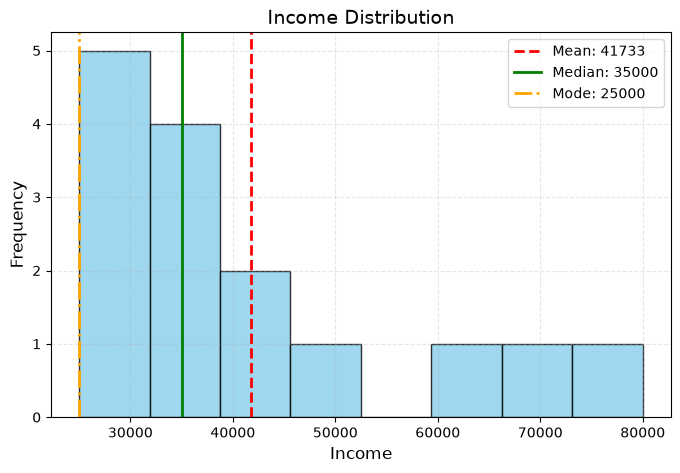

In [3]:
# =============================================================================
# Section 2: Generate Histogram — แสดงการกระจายตัวของรายได้
# =============================================================================
# Histogram แสดงความถี่ของข้อมูลต่อเนื่อง โดยแบ่งเป็น "bins" (ช่วงค่า)
# ช่วยให้เห็นว่าข้อมูล集中在ช่วงใด และมีค่า Mean, Median, Mode เท่าใด

# --- คำนวณค่าสถิติ ---
mean_val = df["Income"].mean()      # ค่าเฉลี่ย (Sum ของทุกค่า / จำนวนข้อมูล)
median_val = df["Income"].median()  # ค่ากลาง (แบ่งข้อมูลเป็น 2 ส่วนเท่ากัน)
mode_val = (df["Income"]).mode()[0] # ฐานนิยม (ค่าที่ปรากฏบ่อยที่สุด)

# --- ตั้งค่าสไตล์กราฟ ---
plt.style.use("default")  # ใช้สไตล์เริ่มต้นของ Matplotlib

# --- สร้าง Figure และ Axes ---
plt.figure(figsize=(8, 5))  # กำหนดขนาดกราฟ (กว้าง 8 นิ้ว, สูง 5 นิ้ว)

# --- วาด Histogram ---
plt.hist(df["Income"], bins=8, color="skyblue", edgecolor="black", alpha=0.8)
#   bins=8    : แบ่งข้อมูลเป็น 8 ช่วง (bin)
#   color     : สีพื้นของแท่ง
#   edgecolor : สีเส้นขอบแท่ง
#   alpha=0.8 : ความโปร่งใส (0 = โปร่งทั้งหมด, 1 =ทึบทั้งหมด)

# --- เพิ่มเส้น Mean, Median, Mode ---
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.0f}")
#   axvline() : วาดเส้นแนวตั้ง
#   linestyle : รูปแบบเส้น (-- = ขีดกลาง, - = เส้นประ, -. = จุดขีด)
plt.axvline(median_val, color="green", linestyle="-", linewidth=2, label=f"Median: {median_val:.0f}")
plt.axvline(mode_val, color="orange", linestyle="-.", linewidth=2, label=f"Mode: {mode_val:.0f}")

# --- เพิ่มองค์ประกอบอื่นๆ ให้กราฟ ---
plt.title("Income Distribution", fontsize=14)      # ชื่อกราฟ
plt.xlabel("Income", fontsize=12)                   # Label แกน X
plt.ylabel("Frequency", fontsize=12)                # Label แกน Y
plt.legend(fontsize=10)                              # แสดง Legend
plt.grid(axis="both", alpha=0.3, linestyle="--")   # แสดงเส้นกริด (แนวนอนและแนวตั้ง)

plt.show()  # แสดงกราฟ

---

## 3. Box Plot — สรุป 5 ค่าสถิติและตรวจหา Outlier

**วัตถุประสงค์:** สรุปการกระจายตัวของ `Income` และระบุค่าผิดปกติ (Outlier)

### Five-Number Summary
Box Plot แสดงค่าสถิติ 5 ตัวในภาพเดียว

| ส่วนประกอบ | ค่า | ความหมาย |
|------------|-----|----------|
| ขอบล่างของกล่อง | **Q1** | เปอร์เซ็นไทล์ที่ 25 |
| เส้นกลางกล่อง | **Median (Q2)** | เปอร์เซ็นไทล์ที่ 50 |
| ขอบบนของกล่อง | **Q3** | เปอร์เซ็นไทล์ที่ 75 |
| หนวดล่าง / บน | **Whisker** | ขอบเขตข้อมูลปกติ |
| จุดนอกหนวด | **Outlier (Flier)** | ค่าผิดปกติ |

### IQR และเกณฑ์ Outlier

**IQR (Interquartile Range) = Q3 − Q1** คือความกว้างของกล่อง แทนการกระจายของข้อมูล 50% ตรงกลาง

เกณฑ์มาตรฐานในการตัดสินว่าเป็น Outlier
```
ขอบล่าง = Q1 − 1.5 × IQR
ขอบบน  = Q3 + 1.5 × IQR
```
ค่าที่อยู่นอกช่วงนี้จะถูกวาดเป็นจุดแยกออกมา

> กล่องกว้าง → ข้อมูลกระจายมาก | กล่องแคบ → ข้อมูลเกาะกลุ่มกัน
> เส้น Median ไม่อยู่กลางกล่อง → ข้อมูลเบ้

### คำอธิบายพารามิเตอร์

```python
plt.boxplot(df[feature], vert=True, patch_artist=True, ...)
```
- `vert=True` → วางกล่องแนวตั้ง (`False` = แนวนอน)
- `patch_artist=True` → **จำเป็นต้องใส่** ถ้าต้องการเติมสีพื้นในกล่อง

การกำหนดสไตล์แต่ละส่วนใช้ dict แยกกัน

| พารามิเตอร์ | ควบคุมส่วน |
|-------------|-----------|
| `boxprops` | ตัวกล่อง |
| `medianprops` | เส้น Median |
| `whiskerprops` | เส้นหนวด |
| `capprops` | ขีดปลายหนวด |
| `flierprops` | จุด Outlier |

/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_97661/1707100420.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True, patch_artist=True,


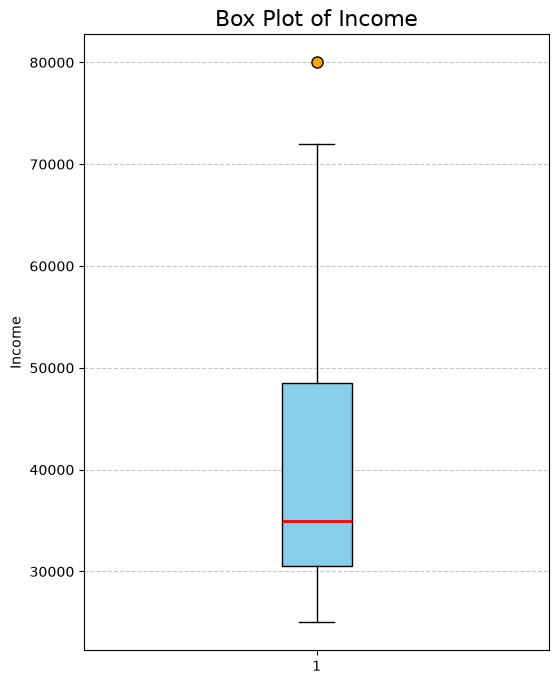

In [4]:
feature = "Income"

# Create Box Plot 
plt.figure(figsize=(6, 8))
plt.boxplot(df[feature], vert=True, patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="black"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1),
            capprops=dict(color="black", linewidth=1),
            flierprops=dict(markerfacecolor="orange", marker="o", markersize=8))

plt.title(f"Box Plot of {feature}", fontsize=16)
plt.ylabel(feature)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

---

## 4. Bar Chart — ความถี่และสัดส่วนของข้อมูลหมวดหมู่

**วัตถุประสงค์:** แสดงจำนวน (Frequency) และสัดส่วน (Proportion) ของแต่ละเพศ เปรียบเทียบกันใน Figure เดียว

### Frequency vs Proportion

| ประเภท | คำอธิบาย | ผลรวม | Method |
|---------|----------|-------|--------|
| **Frequency** | จำนวนนับของแต่ละหมวดหมู่ | = จำนวนข้อมูลทั้งหมด | `value_counts()` |
| **Proportion** | สัดส่วนของแต่ละหมวดหมู่ | = 1.0 (100%) | `value_counts(normalize=True)` |

```
Proportion = ความถี่ของหมวดหมู่ ÷ ความถี่รวมทั้งหมด
```

Proportion มีประโยชน์เมื่อต้องเปรียบเทียบระหว่างชุดข้อมูลที่มีขนาดต่างกัน

### การสร้างหลายกราฟใน Figure เดียว

```python
fig, ax = plt.subplots(2, 1, figsize=(5, 8))
```
- `subplots(2, 1)` → 2 แถว 1 คอลัมน์ → `ax` เป็น array
- `ax[0]` กราฟบน (Frequency) | `ax[1]` กราฟล่าง (Proportion)
- ถ้าเป็น grid 2 มิติ เช่น `subplots(2, 2)` จะเข้าถึงด้วย `ax[0, 1]`

> เมื่อใช้ `ax` ต้องเปลี่ยนจาก `plt.title()` เป็น `ax.set_title()`
> และ `plt.xlabel()` เป็น `ax.set_xlabel()`

### การเติมตัวเลขบนแท่งกราฟ

```python
ax[0].text(i, v + 0.1, str(v), ha="center", fontsize=12)
```
- อาร์กิวเมนต์เรียงเป็น `text(x, y, ข้อความ)`
- `v + 0.1` → ขยับข้อความขึ้นเล็กน้อยไม่ให้ทับยอดแท่ง
- `ha="center"` → Horizontal Alignment จัดกึ่งกลางเทียบกับแท่ง

### พารามิเตอร์ของ `bar()`

```python
ax[0].bar(freq.index, freq.values, color=["#4C9F70", "#FF6F61"], width=0.6, edgecolor="black")
```
- `freq.index` → ชื่อหมวดหมู่ (แกน X) | `freq.values` → ค่าความถี่ (แกน Y)
- `width=0.6` → ความกว้างแท่ง (0–1) ยิ่งน้อยแท่งยิ่งผอม
- `color=[...]` → กำหนดสีทีละแท่งด้วย Hex code

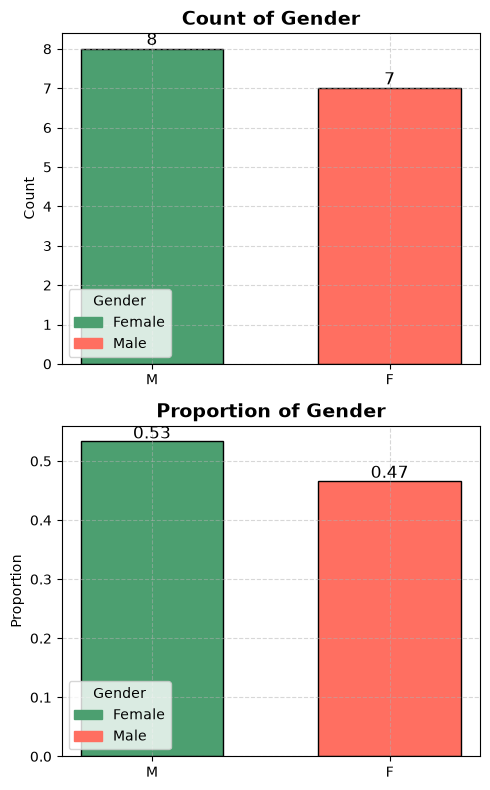

In [5]:
# =============================================================================
# Section 4: Bar Chart — Frequency และ Proportion ของ Gender
# =============================================================================

# --- คำนวณความถี่และสัดส่วน ---
freq = df["Gender"].value_counts()                    # นับจำนวนแต่ละเพศ
prop = df["Gender"].value_counts(normalize=True)      # สัดส่วน (รวมกันได้ 1.0)

# --- สร้าง Figure 2 แถว 1 คอลัมน์ ---
fig, ax = plt.subplots(2, 1, figsize=(5, 8))

# --- กราฟบน: Frequency ---
ax[0].bar(freq.index, freq.values,
          color=["#4C9F70", "#FF6F61"], width=0.6, edgecolor="black")
ax[0].set_title("Count of Gender", fontsize=14, fontweight="bold")
ax[0].set_ylabel("Count")
ax[0].grid(axis="both", linestyle="--", alpha=0.5)

# เติมตัวเลขบนแท่ง
for i, v in enumerate(freq.values):
    ax[0].text(i, v + 0.1, str(v), ha="center", fontsize=12)

# --- กราฟล่าง: Proportion ---
ax[1].bar(prop.index, prop.values,
          color=["#4C9F70", "#FF6F61"], width=0.6, edgecolor="black")
ax[1].set_title("Proportion of Gender", fontsize=14, fontweight="bold")
ax[1].set_ylabel("Proportion")
ax[1].grid(axis="both", linestyle="--", alpha=0.5)

# เติมตัวเลขบนแท่ง (ทศนิยม 2 ตำแหน่ง)
for i, v in enumerate(prop.values):
    ax[1].text(i, v + 0.005, f"{v:.2f}", ha="center", fontsize=12)

# --- Legend อธิบายสี ---
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="#4C9F70", label="Female"),
    mpatches.Patch(color="#FF6F61", label="Male"),
]
ax[0].legend(handles=legend_handles, title="Gender")
ax[1].legend(handles=legend_handles, title="Gender")

plt.tight_layout()   # ปรับระยะห่างไม่ให้ Title ทับกัน
plt.show()

---

## 5. Scatter Plot — ความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข

**วัตถุประสงค์:** ดูความสัมพันธ์ระหว่าง `Age` และ `Income`

### Scatter Plot คืออะไร?
กราฟที่วาดข้อมูลแต่ละแถวเป็น **จุด 1 จุด** บนระนาบ X–Y
ใช้ตรวจสอบความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข 2 ตัว และมองหา Outlier

### รูปแบบความสัมพันธ์ (Correlation)

| รูปแบบจุด | ชื่อ | ความหมาย |
|-----------|------|----------|
| เรียงจากซ้ายล่าง → ขวาบน | **Positive Correlation** | ตัวแปรหนึ่งเพิ่ม อีกตัวเพิ่มตาม |
| เรียงจากซ้ายบน → ขวาล่าง | **Negative Correlation** | ตัวแปรหนึ่งเพิ่ม อีกตัวลดลง |
| กระจายไม่มีรูปแบบ | **No Correlation** | ไม่มีความสัมพันธ์เชิงเส้น |

> **ข้อควรระวัง: Correlation ≠ Causation**
> การที่ตัวแปรสองตัวเคลื่อนไหวไปด้วยกัน ไม่ได้แปลว่าตัวหนึ่งเป็นสาเหตุของอีกตัว

### คำอธิบายพารามิเตอร์

```python
plt.scatter(df["Age"], df["Income"], c="blue", alpha=0.7, edgecolors="black")
```

| พารามิเตอร์ | คำอธิบาย |
|-------------|----------|
| อาร์กิวเมนต์ที่ 1 | ข้อมูลแกน X (Age) |
| อาร์กิวเมนต์ที่ 2 | ข้อมูลแกน Y (Income) |
| `c` | สีของจุด (รับค่าเดี่ยวหรือ Series ก็ได้) |
| `s` | ขนาดของจุด |
| `alpha` | ความโปร่งใส ช่วยให้เห็นจุดที่ซ้อนทับกัน |
| `edgecolors` | สีเส้นขอบจุด |

### สิ่งที่สังเกตได้จากข้อมูลชุดนี้
- `Age` กับ `Income` มีความสัมพันธ์**เชิงบวก**ค่อนข้างชัดเจน — อายุมากขึ้นมักมีรายได้สูงขึ้น
- ลูกค้าอายุ 48 ปี รายได้ 80,000 บาท แยกตัวออกจากแนวโน้มหลักอย่างเห็นได้ชัด

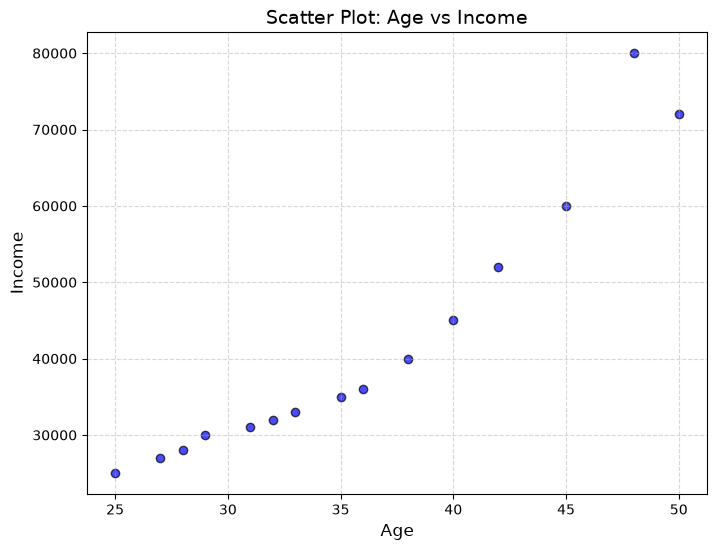

In [6]:
# =============================================================================
# Section 5: Scatter Plot — Age vs Income
# =============================================================================

plt.figure(figsize=(8, 6))

# --- วาด Scatter Plot ---
plt.scatter(df["Age"], df["Income"], c="blue", alpha=0.7, edgecolors="black")
#   อาร์กิวเมนต์ที่ 1 : ข้อมูลแกน X (Age)
#   อาร์กิวเมนต์ที่ 2 : ข้อมูลแกน Y (Income)
#   c          : สีของจุด
#   alpha      : ความโปร่งใส ช่วยให้เห็นจุดที่ซ้อนทับกัน
#   edgecolors : สีเส้นขอบจุด

# --- ตกแต่งกราฟ ---
plt.title("Scatter Plot: Age vs Income", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## 5b. Scatter Plot หลายมิติ — เพิ่มมิติด้วยสีและขนาด

**วัตถุประสงค์:** ใส่ข้อมูลมิติที่ 3 และ 4 ลงใน Scatter Plot 2 มิติ ด้วย **สี** และ **ขนาด** ของจุด

### การแสดงข้อมูลหลายมิติในกราฟ 2D

| มิติ | ช่องทางการแสดงผล | ข้อมูลที่ใช้ |
|------|------------------|-------------|
| 1 | ตำแหน่งแนวนอน (X) | Age |
| 2 | ตำแหน่งแนวตั้ง (Y) | Income |
| 3 | สี (Color) | Gender |
| 4 | ขนาด (Size) | Spend_SCR |

ในทางปฏิบัติสามารถเพิ่มมิติที่ 5 ได้อีกด้วยรูปทรงของจุด (Marker Shape)
แต่ยิ่งใส่หลายมิติ กราฟยิ่งอ่านยาก จึงควรใช้เท่าที่จำเป็น

### การ Map ข้อมูลเป็นสี

```python
colors = df["Gender"].map({"M": "blue", "F": "pink"})
```
- `map()` แปลงค่าใน Series ตาม Dictionary ที่กำหนด
- ผลลัพธ์เป็น Series ของสี ความยาวเท่ากับจำนวนแถว ส่งเข้า `c=` ได้ทันที
- ค่าที่ไม่มีใน dict จะกลายเป็น `NaN` จึงควรตรวจสอบค่าที่เป็นไปได้ทั้งหมดก่อน

### การ Map ข้อมูลเป็นขนาด

```python
sizes = df["Spend_SCR"] * 5
```
- `s` ใน matplotlib มีหน่วยเป็น **พื้นที่** ของจุด ไม่ใช่รัศมี
- คูณ 5 เพื่อขยายสเกลให้มองเห็นความแตกต่างชัดเจนขึ้น
- Spend_SCR สูง → จุดใหญ่ | Spend_SCR ต่ำ → จุดเล็ก

### Legend แบบกำหนดเอง

เมื่อส่งสีเข้า `c=` โดยตรง matplotlib จะไม่รู้จักชื่อกลุ่ม จึงสร้าง Legend อัตโนมัติไม่ได้
ต้องสร้างสัญลักษณ์เองด้วย `mpatches.Patch`

```python
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="blue", label="Male"),
    mpatches.Patch(color="pink", label="Female"),
]
plt.legend(handles=legend_handles, title="Gender", fontsize=10)
```

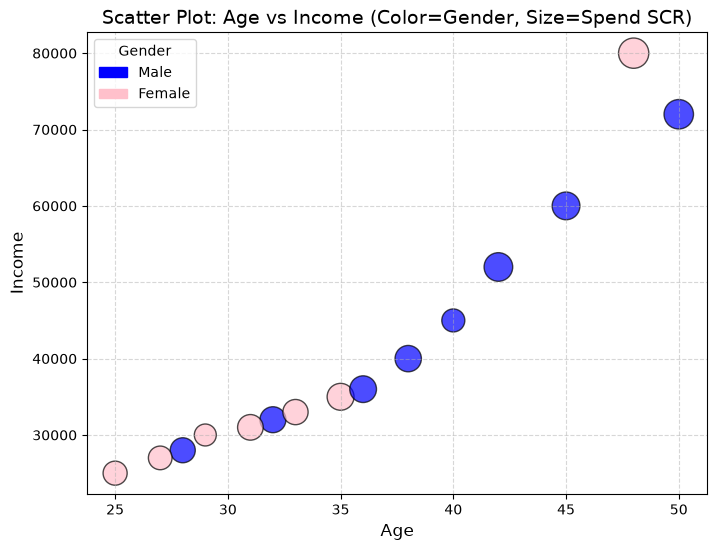

In [7]:
# Define color for gender
colors = df["Gender"].map({"M": "blue", "F": "pink"})

# Define size for Spending Score (Adjust scale)
sizes = df["Spend_SCR"] * 5

# Create Scatter Plot: Age vs Income
plt.figure(figsize=(8, 6))
plt.scatter(df["Age"], df["Income"], c=colors, s=sizes, alpha=0.7, edgecolors="black")

# Details
plt.title("Scatter Plot: Age vs Income (Color=Gender, Size=Spend SCR)", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.grid(True, axis="both", linestyle="--", alpha=0.5)

# Legend for Gender
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="blue", label="Male"),
    mpatches.Patch(color="pink", label="Female")
]
plt.legend(handles=legend_handles, title="Gender", fontsize=10)

plt.show()

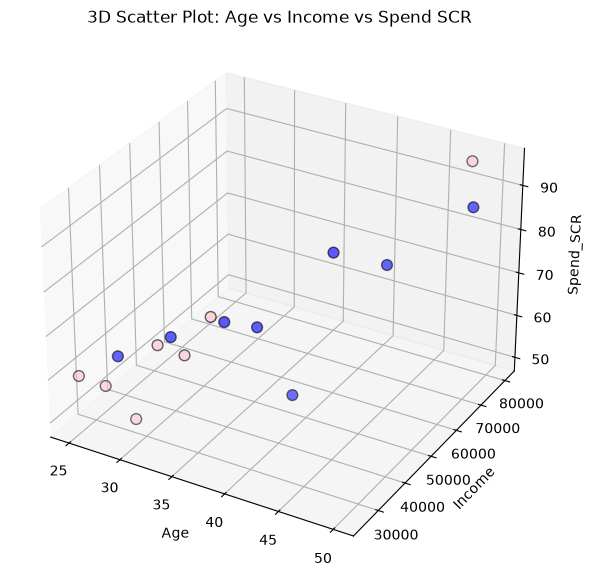

In [8]:
from mpl_toolkits.mplot3d import Axes3D

# กำหนดสีตาม Gender
colors = df["Gender"].map({"M": "blue", "F": "pink"})

# สร้าง 3D Scatter Plot: Age vs Income vs Spend SCR
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["Age"], df["Income"], df["Spend_SCR"],
           c=colors, s=60, alpha=0.8, edgecolors="black")

# ตกแต่งแกน
ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spend_SCR")
ax.set_title("3D Scatter Plot: Age vs Income vs Spend SCR")

plt.show()

In [9]:
import plotly.express as px

# สร้าง Interactive 3D Scatter Plot
fig = px.scatter_3d(df,
                    x="Age", y="Income", z="Spend_SCR",
                    color="Gender", symbol="Is_Member",
                    size="Spend_SCR",
                    title="Interactive 3D Scatter Plot: Age vs Income vs Spend SCR")

fig.show()

---

## 6. Correlation Matrix และ Heatmap

**วัตถุประสงค์:** วัดความสัมพันธ์เชิงเส้นของตัวแปรตัวเลขทุกคู่พร้อมกัน แล้วแสดงผลด้วยสี

### Correlation Coefficient (r)
ค่าสหสัมพันธ์แบบ Pearson มีค่าอยู่ระหว่าง **−1 ถึง +1**

| ช่วงค่า \|r\| | ระดับความสัมพันธ์ |
|---------------|-------------------|
| 0.00 – 0.29 | อ่อน |
| 0.30 – 0.69 | ปานกลาง |
| 0.70 – 1.00 | แข็งแรง |

- **r = +1** ความสัมพันธ์เชิงบวกสมบูรณ์
- **r = 0** ไม่มีความสัมพันธ์เชิงเส้น
- **r = −1** ความสัมพันธ์เชิงลบสมบูรณ์

> r วัดเฉพาะความสัมพันธ์**เชิงเส้น**เท่านั้น
> ข้อมูลที่สัมพันธ์กันแบบโค้ง อาจได้ r ใกล้ 0 ทั้งที่มีความสัมพันธ์ชัดเจน

### คุณสมบัติของ Correlation Matrix
- เป็นเมทริกซ์**สมมาตร** — ค่าที่ `[i, j]` เท่ากับ `[j, i]`
- **เส้นทแยงมุมเป็น 1.00 เสมอ** เพราะเป็นความสัมพันธ์ของตัวแปรกับตัวมันเอง
- `df.corr()` จะคำนวณเฉพาะคอลัมน์ตัวเลข

### คำอธิบายพารามิเตอร์

```python
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
```
- `imshow()` → วาดเมทริกซ์เป็นภาพ โดยแปลงค่าตัวเลขเป็นสี
- `cmap="coolwarm"` → Diverging colormap น้ำเงิน (ค่าต่ำ) → แดง (ค่าสูง) เหมาะกับข้อมูลที่มีจุดกึ่งกลาง
- `interpolation="nearest"` → ไม่เกลี่ยสีระหว่าง cell ทำให้ขอบเขตแต่ละช่องคมชัด

การเติมตัวเลขในแต่ละช่องใช้ Nested Loop
```python
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
```
สังเกตว่า `plt.text(j, i, ...)` สลับลำดับ เพราะ **แกน X คือคอลัมน์ (j)** ส่วน **แกน Y คือแถว (i)**

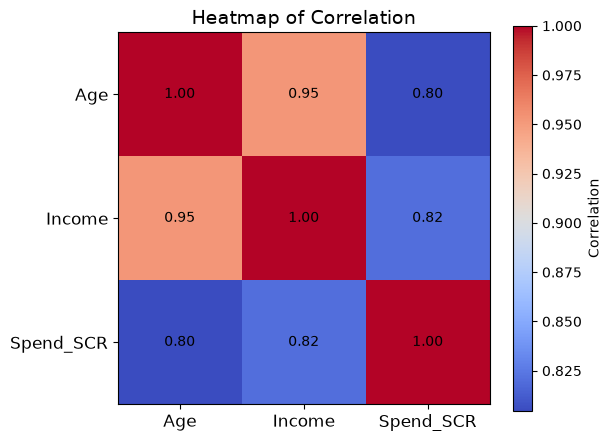

In [10]:
corr = df[["Age","Income","Spend_SCR"]].corr()

# Create Heatmap 
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

# Insert value into each cell
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", 
                 ha="center", va="center", color="black")

# Details
plt.xticks(range(len(corr)), corr.columns, fontsize=12)
plt.yticks(range(len(corr)), corr.columns, fontsize=12)
plt.colorbar(label="Correlation")
plt.title("Heatmap of Correlation", fontsize=14)
plt.grid(False)

plt.show()

---

## 7. Pair Plot — Scatter Plot ทุกคู่ในภาพเดียว

**วัตถุประสงค์:** สำรวจความสัมพันธ์ของตัวแปรตัวเลขทุกคู่พร้อมกันในมุมมองเดียว

### Pair Plot คืออะไร?
ตารางกราฟขนาด n × n เมื่อ n คือจำนวนตัวแปรที่สนใจ

| ตำแหน่ง | เงื่อนไข | กราฟที่แสดง |
|---------|----------|-------------|
| เส้นทแยงมุม | `i == j` | **Histogram** ของตัวแปรนั้น (การกระจายตัว) |
| นอกเส้นทแยงมุม | `i != j` | **Scatter Plot** ระหว่างตัวแปรคู่นั้น |

ในที่นี้มี 3 ตัวแปร จึงได้ตาราง 3 × 3 รวม 9 ช่อง
ช่องบนและล่างเส้นทแยงมุมเป็นข้อมูลชุดเดียวกัน เพียงแต่สลับแกน X กับ Y

### เทคนิคที่ใช้ในโค้ด

**การวนลูปสร้าง Subplot**
```python
for i, f1 in enumerate(features):
    for j, f2 in enumerate(features):
        ax = axes[i, j]
```
- `enumerate()` คืนทั้งลำดับ (`i`) และค่า (`f1`) พร้อมกัน
- `axes[i, j]` เข้าถึง Subplot ตามตำแหน่งแถว–คอลัมน์

**การซ่อน Tick ที่ไม่จำเป็น**
```python
if i == len(features) - 1:
    ax.set_xlabel(f2)     # แสดง label เฉพาะแถวล่างสุด
else:
    ax.set_xticks([])     # แถวอื่นซ่อนตัวเลขแกน X
```
แสดง Label เฉพาะขอบนอกช่วยลดความรก ทำให้กราฟอ่านง่ายขึ้นมาก

**การจัดระยะห่าง**
- `plt.suptitle()` → ชื่อรวมของทั้ง Figure (ต่างจาก `plt.title()` ที่เป็นของแต่ละ Subplot)
- `plt.tight_layout()` → ปรับระยะห่างอัตโนมัติไม่ให้ Label ทับกัน

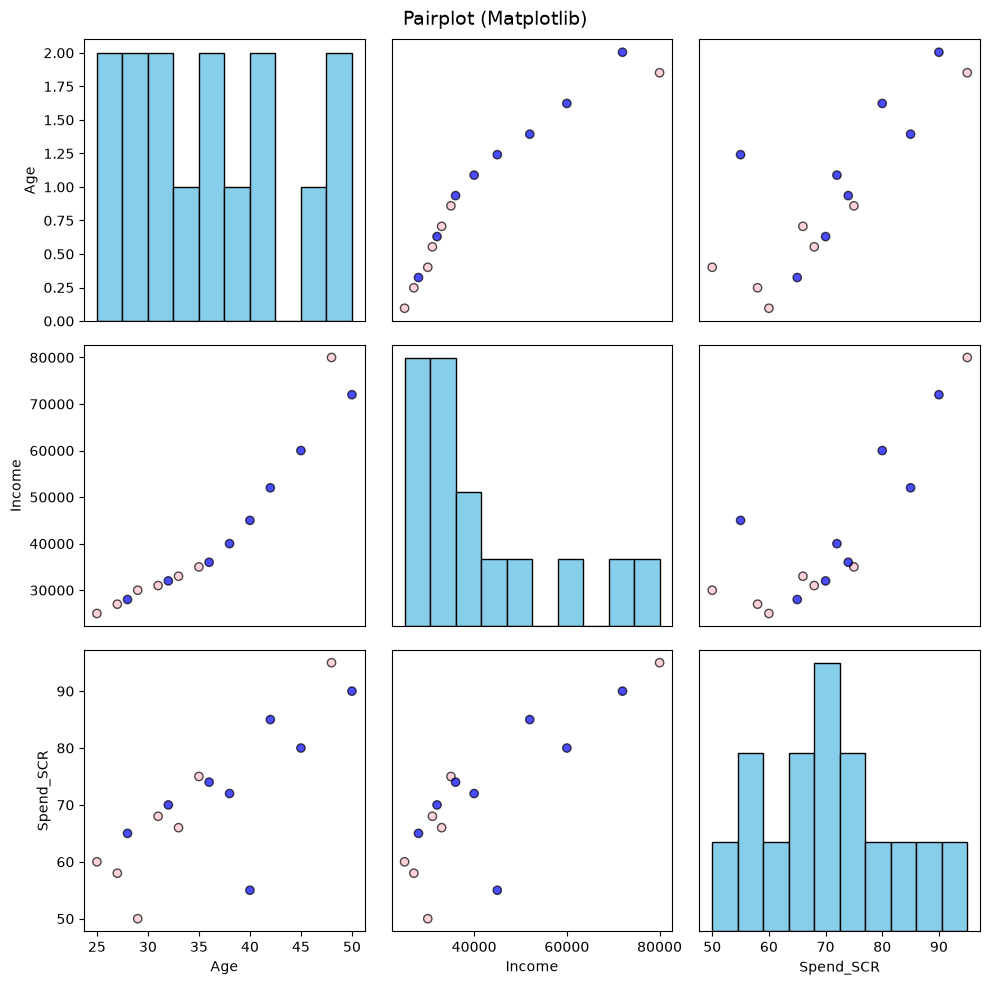

In [11]:
features = ["Age","Income","Spend_SCR"]
colors = df["Gender"].map({"M":"blue","F":"pink"})

# สร้าง Pairplot แบบ manual
fig, axes = plt.subplots(len(features), len(features), figsize=(10,10))

for i, f1 in enumerate(features):
    for j, f2 in enumerate(features):
        ax = axes[i,j]
        if i == j:
            ax.hist(df[f1], color="skyblue", edgecolor="black")
        else:
            ax.scatter(df[f2], df[f1], c=colors, alpha=0.7, edgecolors="black")
        if i == len(features)-1:
            ax.set_xlabel(f2)
        else:
            ax.set_xticks([])
        if j == 0:
            ax.set_ylabel(f1)
        else:
            ax.set_yticks([])

plt.suptitle("Pairplot (Matplotlib)", fontsize=14)
plt.tight_layout()
plt.show()

---

## 8. Pie Chart — สัดส่วนของส่วนประกอบทั้งหมด

**วัตถุประสงค์:** แสดงสัดส่วนของแต่ละเพศเทียบกับจำนวนลูกค้าทั้งหมด

### เมื่อไรควรใช้ Pie Chart?

**เหมาะ** เมื่อ
- ต้องการสื่อสัดส่วนเทียบกับ **ทั้งหมด (Part-to-Whole)**
- มีหมวดหมู่ **ไม่เกิน 5–6 กลุ่ม**
- ผลรวมของทุกส่วนมีความหมายเป็น 100%

**ไม่เหมาะ** เมื่อ
- มีหมวดหมู่จำนวนมาก ชิ้นเล็ก ๆ จะอ่านไม่ออก
- ต้องการ**เปรียบเทียบค่า**ระหว่างกลุ่มอย่างแม่นยำ — สายตาคนเราเปรียบเทียบความยาวได้ดีกว่ามุม จึงควรใช้ Bar Chart แทน

### คำอธิบายพารามิเตอร์

```python
plt.pie(count_vals, labels=count_vals.index,
        autopct="%1.1f%%", colors=["skyblue", "salmon"], startangle=90)
```

| พารามิเตอร์ | คำอธิบาย |
|-------------|----------|
| อาร์กิวเมนต์ที่ 1 | ค่าที่ใช้คำนวณสัดส่วน (จะถูก normalize ให้รวมเป็น 100% ให้เอง) |
| `labels` | ชื่อกำกับแต่ละชิ้น |
| `autopct` | รูปแบบตัวเลขเปอร์เซ็นต์บนชิ้น — `"%1.1f%%"` = ทศนิยม 1 ตำแหน่ง ตามด้วย % |
| `colors` | สีของแต่ละชิ้น เรียงตามลำดับข้อมูล |
| `startangle=90` | เริ่มวาดชิ้นแรกที่ตำแหน่ง 12 นาฬิกา อ่านง่ายกว่าค่าเริ่มต้น |

พารามิเตอร์อื่นที่ใช้บ่อย
- `explode=(0.1, 0)` → ดึงชิ้นที่ต้องการเน้นออกจากวงกลม
- `shadow=True` → เพิ่มเงาให้ดูมีมิติ

> ควรกำหนด `figsize` ให้กว้างเท่ากับสูง เพื่อให้ได้วงกลมที่ไม่บิดเบี้ยว

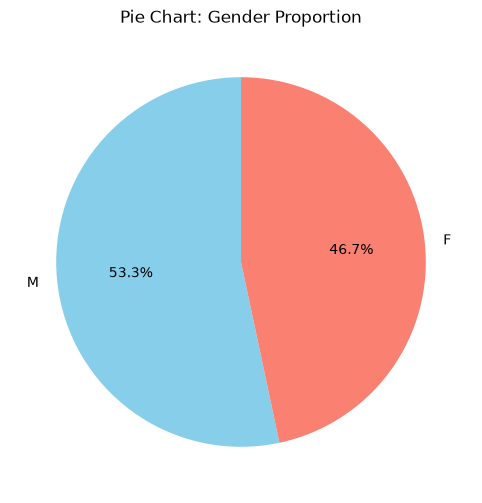

In [12]:
# นับจำนวนแต่ละ Gender
count_vals = df["Gender"].value_counts()

# สร้าง Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(count_vals, labels=count_vals.index,
        autopct="%1.1f%%", colors=["skyblue", "salmon"],
        startangle=90)
plt.title("Pie Chart: Gender Proportion")
plt.show()

---

## 9. Grouped Bar Chart — เปรียบเทียบข้าม 2 หมวดหมู่

**วัตถุประสงค์:** เปรียบเทียบรายได้เฉลี่ย แยกตาม `Gender` และ `Is_Member` พร้อมกัน

### GroupBy → Aggregate → Unstack

ขั้นตอนการเตรียมข้อมูลมี 3 ส่วน
```python
group_mean = df.groupby(["Gender", "Is_Member"])["Income"].mean().unstack()
```

| ขั้น | คำสั่ง | ผลลัพธ์ |
|------|--------|---------|
| 1 | `groupby(["Gender", "Is_Member"])` | จับกลุ่มข้อมูลตาม 2 คอลัมน์ |
| 2 | `["Income"].mean()` | คำนวณค่าเฉลี่ยของแต่ละกลุ่ม → Series ที่มี MultiIndex |
| 3 | `.unstack()` | ย้าย Index ชั้นในสุดขึ้นไปเป็น**คอลัมน์** → ได้ตาราง 2 มิติ |

`unstack()` เป็นขั้นตอนสำคัญ เพราะ `plot(kind="bar")` จะวาด **1 คอลัมน์ = 1 ชุดแท่ง**
ถ้าไม่ทำ จะได้แท่งเรียงยาวแบบ MultiIndex ซึ่งอ่านยาก

ฟังก์ชัน Aggregate อื่นที่ใช้ได้: `.sum()`, `.count()`, `.median()`, `.max()`, `.min()`, `.std()`

### การ Plot จาก DataFrame โดยตรง

```python
group_mean.plot(kind="bar", figsize=(8, 6), color=["skyblue", "salmon"], edgecolor="black")
```
- pandas มี `.plot()` ในตัวซึ่งเรียกใช้ matplotlib เบื้องหลัง
- ใช้ **Index เป็นแกน X** และสร้าง Legend จาก **ชื่อคอลัมน์** ให้อัตโนมัติ
- `kind` ที่ใช้ได้: `"bar"`, `"barh"`, `"line"`, `"hist"`, `"box"`, `"pie"`, `"scatter"`

### Grouped vs Stacked
- **Grouped** (ค่าเริ่มต้น) → แท่งเรียงข้างกัน เหมาะกับการ**เปรียบเทียบค่าระหว่างกลุ่ม**
- **Stacked** → แท่งซ้อนทับกัน เหมาะกับการดู**ผลรวมและองค์ประกอบ** (ดู Section 10)

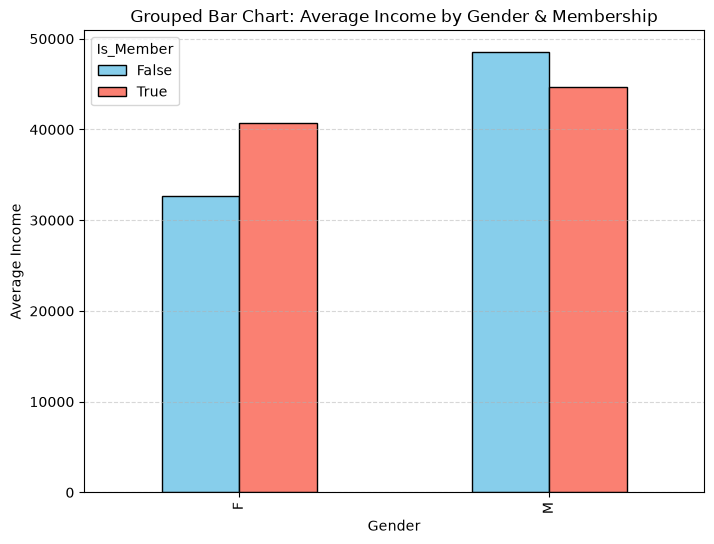

In [13]:
# ค่าเฉลี่ย Income แยกตาม Gender และ Is_Member
group_mean = df.groupby(["Gender","Is_Member"])["Income"].mean().unstack()

# Grouped Bar Chart
group_mean.plot(kind="bar", figsize=(8,6), color=["skyblue","salmon"], edgecolor="black")
plt.title("Grouped Bar Chart: Average Income by Gender & Membership")
plt.ylabel("Average Income")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

---

## 10. Stacked Bar Chart และการวิเคราะห์ 2 ตัวแปรหมวดหมู่

**วัตถุประสงค์:** ดูจำนวนและองค์ประกอบของลูกค้า แยกตาม `Gender` และ `Is_Member`
Section นี้แสดง 3 วิธีในการวิเคราะห์ข้อมูลหมวดหมู่ 2 ตัวพร้อมกัน

### 1) Stacked Bar Chart

```python
group_count = df.groupby(["Gender", "Is_Member"]).size().unstack()
group_count.plot(kind="bar", stacked=True, ...)
```
- `.size()` → **นับจำนวนแถว**ในแต่ละกลุ่ม (ต่างจาก `.count()` ที่นับเฉพาะค่าที่ไม่เป็น NaN แยกรายคอลัมน์)
- `stacked=True` → วางแท่งซ้อนกันแทนการเรียงข้างกัน

**ข้อดี** เห็นผลรวมของแต่ละกลุ่มทันทีจากความสูงรวมของแท่ง
**ข้อเสีย** เปรียบเทียบชิ้นส่วนที่ไม่ได้เริ่มจากฐานเดียวกันได้ยาก

### 2) Cross-tabulation + Heatmap

```python
ct = pd.crosstab(df["Gender"], df["Is_Member"])
```
`pd.crosstab()` เป็นทางลัดสำหรับสร้างตารางความถี่ 2 ทาง (Contingency Table)
ให้ผลเทียบเท่า `groupby().size().unstack()` แต่เขียนสั้นและอ่านง่ายกว่า

พารามิเตอร์ที่มีประโยชน์
- `normalize="index"` → แปลงเป็นสัดส่วนของแต่ละ**แถว**
- `normalize="columns"` → สัดส่วนของแต่ละ**คอลัมน์**
- `margins=True` → เพิ่มแถว/คอลัมน์ผลรวม

การวาด Heatmap ใช้หลักการเดียวกับ Section 6 คือ `imshow()` แล้ววนลูปเติมตัวเลขด้วย `plt.text()`

### 3) Mosaic Plot

```python
from statsmodels.graphics.mosaicplot import mosaic
mosaic(df, ["Gender", "Is_Member"])
```
แสดงความถี่ด้วย **พื้นที่** ของสี่เหลี่ยม — กลุ่มที่มีจำนวนมากจะได้พื้นที่ใหญ่
ทำให้เห็นความสัมพันธ์ระหว่างตัวแปรทั้งสองได้ในภาพเดียว

> ต้องติดตั้ง `statsmodels` ก่อน: `pip install statsmodels`

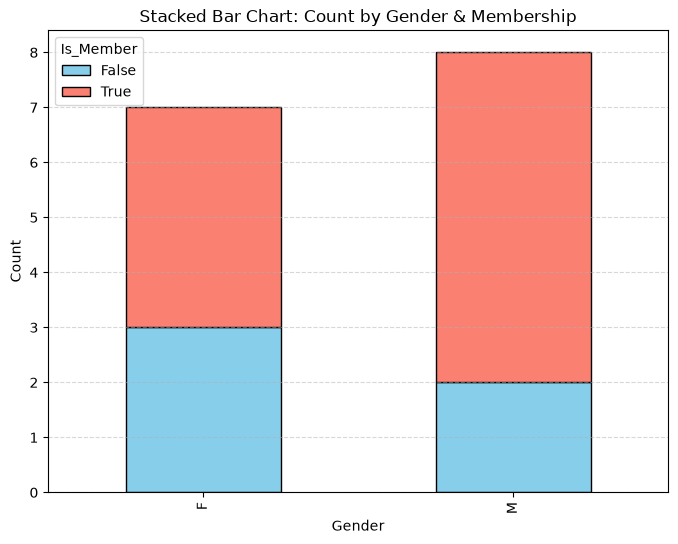

In [14]:
# Count ของ Gender และ Is_Member
group_count = df.groupby(["Gender","Is_Member"]).size().unstack()

# Stacked Bar Chart
group_count.plot(kind="bar", stacked=True, figsize=(8,6), color=["skyblue","salmon"], edgecolor="black")
plt.title("Stacked Bar Chart: Count by Gender & Membership")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

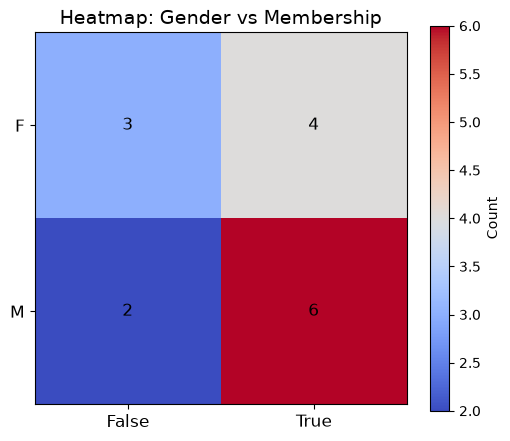

In [15]:
# สร้าง Cross-tabulation
ct = pd.crosstab(df["Gender"], df["Is_Member"])

# Plot Heatmap
plt.figure(figsize=(6,5))
plt.imshow(ct, cmap="coolwarm", interpolation="nearest")

# เพิ่มค่าในแต่ละ cell
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        plt.text(j, i, ct.iloc[i, j], ha="center", va="center", color="black", fontsize=12)

# ตกแต่งแกน
plt.xticks(range(ct.shape[1]), ct.columns, fontsize=12)
plt.yticks(range(ct.shape[0]), ct.index, fontsize=12)
plt.colorbar(label="Count")
plt.title("Heatmap: Gender vs Membership", fontsize=14)
plt.show()

<Figure size 800x600 with 0 Axes>

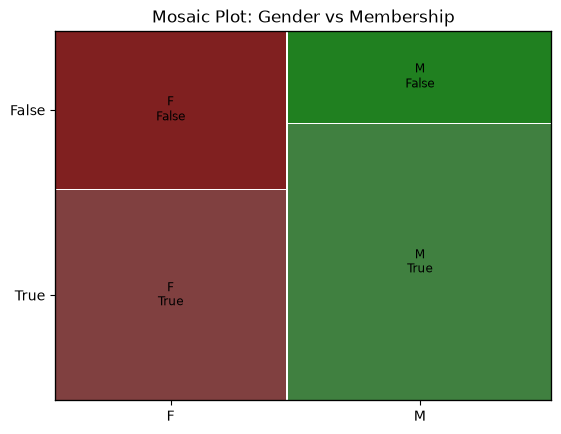

In [16]:
from statsmodels.graphics.mosaicplot import mosaic

# สร้าง Mosaic Plot
plt.figure(figsize=(8,6))
mosaic(df, ["Gender", "Is_Member"])
plt.title("Mosaic Plot: Gender vs Membership")
plt.show()

---